# RAF-DB Landmark Graph Transformer Training

Self-contained notebook. It downloads the precomputed Hugging Face dataset `Pelmeshek/raf-db-7emotions-mediapipe-768`, reads the ready-made `train/val/test` splits and landmark labels, trains baselines and a landmark graph transformer, and saves local results.

This version is prepared for **Google Colab 2025.07** and installs runtime packages with **uv**. MediaPipe is pinned to the legacy `0.10.18` line because this notebook uses `mp.solutions.face_mesh` constants to build the FaceMesh adjacency graph. Newer MediaPipe builds such as `0.10.35` no longer expose the same `mp.solutions` shortcut.

Run the setup cell first. If packages are installed or repaired, the runtime will restart automatically. After reconnecting, run the notebook again from the top; the setup cell will skip reinstalling when the pinned environment is already present.


In [ ]:
# Colab 2025.07 setup with uv for legacy MediaPipe Solutions API.
# Run this cell first. If it changes binary packages, it restarts the runtime automatically.

from __future__ import annotations

import os
import shutil
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

# Set True only if you want to repair/reinstall the pinned packages again.
FORCE_REINSTALL = False
RESTART_AFTER_INSTALL = True

# Important:
# - MediaPipe 0.10.18 keeps the legacy mp.solutions.face_mesh API used below.
# - MediaPipe 0.10.18 requires NumPy < 2, so Colab's NumPy 2.x must be replaced.
# - NumPy 1.26.4 is used instead of 1.23.5 because it is newer and works with
#   pandas/scipy/sklearn wheels on Python 3.11.
# - Torch is intentionally NOT pinned here. Keep Colab's preinstalled torch/CUDA build.
PINNED_PACKAGES = [
    "numpy==1.26.4",
    "pandas==2.2.3",
    "scipy==1.14.1",
    "scikit-learn==1.5.2",
    "pyarrow==21.0.0",
    "pillow==10.4.0",
    "protobuf==4.25.5",
    "mediapipe==0.10.18",
    "datasets==4.8.5",
    "huggingface-hub==1.16.1",
    "hf-transfer==0.1.8",
    "tqdm==4.66.5",
    "xgboost==2.1.1",
    "matplotlib==3.9.2",
    "seaborn==0.13.2",
]

# Reinstall binary packages that commonly cause ABI mismatches after partial installs.
REINSTALL_PACKAGES = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "pyarrow",
    "pillow",
    "protobuf",
    "mediapipe",
    "matplotlib",
]

PACKAGE_IMPORT_NAMES = {
    "scikit-learn": "sklearn",
    "pillow": "PIL",
    "huggingface-hub": "huggingface_hub",
    "hf-transfer": "hf_transfer",
}

def dist_name(requirement: str) -> str:
    return requirement.split("==", 1)[0]

def expected_version(requirement: str) -> str:
    return requirement.split("==", 1)[1]

def installed_version(distribution_name: str) -> str | None:
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        return None

expected = {dist_name(req): expected_version(req) for req in PINNED_PACKAGES}
current = {name: installed_version(name) for name in expected}

needs_install = FORCE_REINSTALL or any(current[name] != expected[name] for name in expected)

print("Python:", sys.version)
print("Package status:")
for name in expected:
    marker = "OK" if current[name] == expected[name] else "CHANGE"
    print(f"  {name:18s} installed={current[name]!s:12s} expected={expected[name]:8s} {marker}")

if not needs_install:
    print("\nEnvironment already matches the pinned package set. Continuing without reinstall.")
else:
    uv_bin = shutil.which("uv")
    if uv_bin is None:
        print("\nInstalling uv with the official standalone installer...")
        subprocess.check_call("curl -LsSf https://astral.sh/uv/install.sh | sh", shell=True)
        candidate_paths = [
            os.path.expanduser("~/.local/bin/uv"),
            "/root/.local/bin/uv",
        ]
        uv_bin = next((p for p in candidate_paths if os.path.exists(p)), None)
        if uv_bin is None:
            os.environ["PATH"] = os.path.expanduser("~/.local/bin") + os.pathsep + os.environ.get("PATH", "")
            uv_bin = shutil.which("uv")
        if uv_bin is None:
            raise RuntimeError("uv was installed, but the uv executable was not found on PATH.")

    print(f"\nUsing uv: {uv_bin}")

    cmd = [
        uv_bin,
        "pip",
        "install",
        "--system",
        "--upgrade",
    ]

    for package_name in REINSTALL_PACKAGES:
        cmd.extend(["--reinstall-package", package_name])

    cmd.extend(PINNED_PACKAGES)

    print("\nRunning:")
    print(" ".join(cmd))
    subprocess.check_call(cmd)

    print("\nPackage installation finished.")
    if RESTART_AFTER_INSTALL:
        print("Restarting Colab runtime now. After reconnecting, run the notebook from the top again.", flush=True)
        os.kill(os.getpid(), 9)


Python: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]
Package status:
  numpy              installed=1.26.3       expected=1.26.4   CHANGE
  pandas             installed=None         expected=2.2.3    CHANGE
  scipy              installed=None         expected=1.14.1   CHANGE
  scikit-learn       installed=None         expected=1.5.2    CHANGE
  pyarrow            installed=None         expected=21.0.0   CHANGE
  pillow             installed=10.2.0       expected=10.4.0   CHANGE
  protobuf           installed=None         expected=4.25.5   CHANGE
  mediapipe          installed=None         expected=0.10.18  CHANGE
  datasets           installed=None         expected=4.8.5    CHANGE
  huggingface-hub    installed=None         expected=1.16.1   CHANGE
  hf-transfer        installed=None         expected=0.1.8    CHANGE
  tqdm               installed=None         expected=4.66.5   CHANGE
  xgboost            installed=None         expected=2.1.1    CHANGE
  matplotlib         install

downloading uv 0.11.16 x86_64-unknown-linux-gnu


installing to /root/.local/bin
  uv
  uvx
everything's installed!

To add $HOME/.local/bin to your PATH, either restart your shell or run:

    source $HOME/.local/bin/env (sh, bash, zsh)
    source $HOME/.local/bin/env.fish (fish)

Using uv: /root/.local/bin/uv

Running:
/root/.local/bin/uv pip install --system --upgrade --reinstall-package numpy --reinstall-package pandas --reinstall-package scipy --reinstall-package scikit-learn --reinstall-package pyarrow --reinstall-package pillow --reinstall-package protobuf --reinstall-package mediapipe --reinstall-package matplotlib numpy==1.26.4 pandas==2.2.3 scipy==1.14.1 scikit-learn==1.5.2 pyarrow==21.0.0 pillow==10.4.0 protobuf==4.25.5 mediapipe==0.10.18 datasets==4.8.5 huggingface-hub==1.16.1 hf-transfer==0.1.8 tqdm==4.66.5 xgboost==2.1.1 matplotlib==3.9.2 seaborn==0.13.2


Using Python 3.11.10 environment at: /usr
Resolved 72 packages in 418ms
Prepared 71 packages in 6.13s
Uninstalled 21 packages in 283ms


## Verify Environment

After the setup cell restarts the runtime, reconnect and run the notebook from the top. The setup cell should then skip installation, and this sanity check must pass before training cells are executed.


In [1]:
# Environment sanity check.
# Run after the setup cell has completed and the runtime has restarted.

import sys

import mediapipe as mp
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy
import sklearn
import torch

print("Python:", sys.version)
print("MediaPipe:", mp.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyArrow:", pa.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Hard sanity checks for the parts this notebook needs.
_ = np.random.RandomState(42)
_ = pd.DataFrame({"x": [1, 2, 3]})
_ = mp.solutions.face_mesh.FACEMESH_TESSELATION
_ = mp.solutions.face_mesh.FACEMESH_CONTOURS
_ = mp.solutions.face_mesh.FACEMESH_IRISES

print("Sanity check passed.")


Python: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]
MediaPipe: 0.10.18
NumPy: 1.26.4
Pandas: 2.2.3
PyArrow: 21.0.0
SciPy: 1.14.1
Scikit-learn: 1.5.2
Torch: 2.4.1+cu124
CUDA available: True
Sanity check passed.


In [2]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 

## Imports And Config

Edit only this cell for normal runs.


In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json
import os
import random
import time
import warnings

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# MediaPipe legacy Solutions API. This notebook pins mediapipe==0.10.18.
FACE_MESH = mp.solutions.face_mesh

warnings.filterwarnings('ignore', message='IProgress not found.*')
pd.set_option('display.max_columns', 200)
os.environ.setdefault('HF_HUB_ENABLE_HF_TRANSFER', '1')

HF_DATASET_ID = 'Pelmeshek/raf-db-7emotions-mediapipe-768'
RUN_DIR = Path('rafdb_precomputed_landmark_graph_run')
RESULTS_DIR = RUN_DIR / 'results'
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'

SEED = 42
MAX_SAMPLES_PER_SPLIT = None  # set e.g. 2048 for debugging; keep None for full splits
LANDMARK_COLUMN = 'landmarks_stable_eye_norm'
LANDMARK_IMAGE_SIZE = 768
EXPECTED_SPLITS = ('train', 'val', 'test')

BATCH_SIZE = 128
NUM_WORKERS = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

MODEL_KINDS = ['majority', 'logreg_geometry', 'xgboost_geometry', 'flattened_mlp', 'graph_transformer']

TRAINING_CONFIG = {
    'lr': 3e-4,
    'weight_decay': 1e-2,
    'label_smoothing': 0.05,
    'max_epochs': 80,
    'early_stopping_patience': 12,
    'scheduler_patience': 4,
    'max_grad_norm': 1.0,
}

GRAPH_TRANSFORMER_CONFIG = {
    'd_model': 128,
    'num_layers': 4,
    'num_heads': 8,
    'ffn_dim': 256,
    'dropout': 0.20,
}

FLATTENED_MLP_CONFIG = {
    'hidden_dims': (512, 128),
    'dropout': 0.25,
}

TARGET_LABELS = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral']
TARGET_LABEL_TO_ID = {name: idx for idx, name in enumerate(TARGET_LABELS)}
ID_TO_TARGET_LABEL = {idx: name for name, idx in TARGET_LABEL_TO_ID.items()}
NUM_CLASSES = len(TARGET_LABELS)
LANDMARK_COUNT = 478

for path_obj in (RESULTS_DIR, CHECKPOINT_DIR):
    path_obj.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('device:', DEVICE)
print('mediapipe version:', mp.__version__)
print('results dir:', RESULTS_DIR.resolve())


device: cuda
mediapipe version: 0.10.18
results dir: /workspace/rafdb_precomputed_landmark_graph_run/results


## Load Precomputed Hugging Face Dataset

This notebook uses the already processed dataset `Pelmeshek/raf-db-7emotions-mediapipe-768`.

It does not extract MediaPipe landmarks or remap labels locally. Instead, it reads the ready-made `train`, `val`, and `test` splits and verifies that the dataset label order already matches the project order: `anger, disgust, fear, happiness, sadness, surprise, neutral`.


In [4]:
dataset_dict = load_dataset(HF_DATASET_ID)
split_names = tuple(dataset_dict.keys())
missing_splits = sorted(set(EXPECTED_SPLITS) - set(split_names))
if missing_splits:
    raise ValueError(f'Missing expected splits: {missing_splits}; found {split_names}')

split_datasets = {}
for split_name in EXPECTED_SPLITS:
    split_ds = dataset_dict[split_name]
    if MAX_SAMPLES_PER_SPLIT is not None:
        split_ds = split_ds.select(range(min(int(MAX_SAMPLES_PER_SPLIT), len(split_ds))))
    split_datasets[split_name] = split_ds

label_names = list(split_datasets['train'].features['label'].names)
if label_names != TARGET_LABELS:
    raise ValueError(f'Unexpected label order: {label_names}')

label_table = pd.DataFrame([
    {
        'label_id': idx,
        'label_name': name,
    }
    for idx, name in enumerate(label_names)
])

split_rows = []
for split_name in EXPECTED_SPLITS:
    split_ds = split_datasets[split_name]
    counts = pd.Series(split_ds['label']).map(ID_TO_TARGET_LABEL).value_counts()
    for label_name in TARGET_LABELS:
        split_rows.append({
            'split': split_name,
            'label_name': label_name,
            'count': int(counts.get(label_name, 0)),
        })

split_counts_df = pd.DataFrame(split_rows).pivot(index='split', columns='label_name', values='count').fillna(0).astype(int)
print({split_name: len(split_datasets[split_name]) for split_name in EXPECTED_SPLITS})
display(label_table)
display(split_counts_df[TARGET_LABELS])


README.md:   0%|          | 0.00/2.75k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/110M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/112M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/112M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/1.57G [00:00<?, ?B/s]

...

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

{'train': 14329, 'val': 3071, 'test': 3071}


,label_id,label_name
0,0,anger
1,1,disgust
2,2,fear
3,3,happiness
4,4,sadness
5,5,surprise
6,6,neutral


label_name,anger,disgust,fear,happiness,sadness,surprise,neutral
split,,,,,,,
test,611,131,54,893,369,243,770
train,2850,614,248,4170,1722,1133,3592
val,610,132,53,894,369,243,770


## Precomputed Landmark Coverage

The dataset already contains `landmark_success`, `failure_reason`, and `landmarks_stable_eye_norm`.

This section builds compact tables from the published splits, keeps only rows with successful landmark extraction for model training, and reports coverage before training.


In [5]:
KEEP_COLUMNS = [
    'sample_id',
    'source_index',
    'split',
    'hf_label_id',
    'hf_label_name',
    'label',
    'label_name',
    'mediapipe_image_size',
    'landmark_success',
    'failure_reason',
    LANDMARK_COLUMN,
    'inter_eye_scale',
    'roll_radians',
]

def dataset_split_to_frame(split_name: str) -> pd.DataFrame:
    split_ds = split_datasets[split_name]
    drop_columns = [column for column in split_ds.column_names if column not in KEEP_COLUMNS]
    slim_ds = split_ds.remove_columns(drop_columns) if drop_columns else split_ds
    frame = slim_ds.to_pandas()
    frame['split'] = split_name
    frame['label_id'] = frame['label'].astype(np.int64)
    frame['label_name'] = frame['label_name'].astype(str)
    frame['landmarks_norm'] = frame[LANDMARK_COLUMN]
    return frame

split_frames = {split_name: dataset_split_to_frame(split_name) for split_name in EXPECTED_SPLITS}


In [6]:
all_df = pd.concat([split_frames[split_name] for split_name in EXPECTED_SPLITS], ignore_index=True)
success_df = all_df.loc[all_df['landmark_success']].copy().reset_index(drop=True)
failure_df = all_df.loc[~all_df['landmark_success']].copy().reset_index(drop=True)

coverage_rows = []
for split_name in EXPECTED_SPLITS:
    split_frame = all_df.loc[all_df['split'] == split_name]
    success_count = int(split_frame['landmark_success'].sum())
    total_count = int(len(split_frame))
    coverage_rows.append({
        'split': split_name,
        'success_rows': success_count,
        'failure_rows': total_count - success_count,
        'total_rows': total_count,
        'coverage': float(success_count / max(total_count, 1)),
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage = float(success_df.shape[0] / max(all_df.shape[0], 1))
coverage_by_split = {row['split']: float(row['coverage']) for _, row in coverage_df.iterrows()}

for split_name in EXPECTED_SPLITS:
    usable = int((success_df['split'] == split_name).sum())
    if usable == 0:
        raise ValueError(f'No successful landmark rows available for split={split_name}')

print('overall usable rows:', len(success_df))
print('overall coverage:', round(coverage, 4))
display(coverage_df)
display(success_df.groupby(['split', 'label_name']).size().unstack(fill_value=0)[TARGET_LABELS])
if len(failure_df) > 0:
    display(
        failure_df.groupby(['split', 'failure_reason']).size().rename('count').reset_index().sort_values('count', ascending=False).head(20)
    )


overall usable rows: 18078
overall coverage: 0.8831


,split,success_rows,failure_rows,total_rows,coverage
0,train,12679,1650,14329,0.884849
1,val,2679,392,3071,0.872354
2,test,2720,351,3071,0.885705


label_name,anger,disgust,fear,happiness,sadness,surprise,neutral
split,,,,,,,
test,495,112,45,780,299,219,770
train,2327,532,203,3545,1468,1013,3591
val,479,112,41,753,307,217,770


,split,failure_reason,count
1,train,no_face_detected,1650
2,val,no_face_detected,392
0,test,no_face_detected,351


## Prepare Split Tensors

The published dataset already contains fixed `train`, `val`, and `test` splits, so this notebook does not re-split the data.


In [7]:
def stack_landmarks(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, list[str]]:
    landmarks = np.stack([
        np.asarray(value.tolist() if hasattr(value, 'tolist') else value, dtype=np.float32)
        for value in frame['landmarks_norm'].to_list()
    ]).astype(np.float32)
    labels = frame['label_id'].to_numpy(dtype=np.int64)
    sample_ids = frame['sample_id'].astype(str).tolist()
    return landmarks, labels, sample_ids

train_df = success_df.loc[success_df['split'] == 'train'].reset_index(drop=True)
val_df = success_df.loc[success_df['split'] == 'val'].reset_index(drop=True)
test_df = success_df.loc[success_df['split'] == 'test'].reset_index(drop=True)

X_train, y_train, ids_train = stack_landmarks(train_df)
X_val, y_val, ids_val = stack_landmarks(val_df)
X_test, y_test, ids_test = stack_landmarks(test_df)

split_df = success_df[['sample_id', 'source_index', 'label_id', 'label_name', 'split']].copy()

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
display(split_df.groupby(['split', 'label_name']).size().unstack(fill_value=0)[TARGET_LABELS])


X_train: (12679, 478, 3)
X_val: (2679, 478, 3)
X_test: (2720, 478, 3)


label_name,anger,disgust,fear,happiness,sadness,surprise,neutral
split,,,,,,,
test,495,112,45,780,299,219,770
train,2327,532,203,3545,1468,1013,3591
val,479,112,41,753,307,217,770


## Metrics And Geometry Features


In [8]:
def metric_bundle(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, Any]:
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=TARGET_LABELS,
        output_dict=True,
        zero_division=0,
    )
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'classification_report': report,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).tolist(),
        'per_class_f1': {label: float(report[label]['f1-score']) for label in TARGET_LABELS},
    }

def comparison_row(model_name: str, val_metrics: dict[str, Any], test_metrics: dict[str, Any], latency_ms: float) -> dict[str, Any]:
    row = {
        'model': model_name,
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_balanced_accuracy': val_metrics['balanced_accuracy'],
        'test_accuracy': test_metrics['accuracy'],
        'test_macro_f1': test_metrics['macro_f1'],
        'test_balanced_accuracy': test_metrics['balanced_accuracy'],
        'latency_ms_per_sample': latency_ms,
    }
    for label in TARGET_LABELS:
        row[f'{label}_f1'] = test_metrics['per_class_f1'][label]
    return row

def point_distance(batch: np.ndarray, a: int, b: int) -> np.ndarray:
    return np.linalg.norm(batch[:, a, :] - batch[:, b, :], axis=1)

def axis_delta(batch: np.ndarray, a: int, b: int, axis: int) -> np.ndarray:
    return batch[:, a, axis] - batch[:, b, axis]

def geometry_features(batch: np.ndarray) -> np.ndarray:
    features = [
        point_distance(batch, 61, 291),
        point_distance(batch, 13, 14),
        point_distance(batch, 0, 17),
        point_distance(batch, 159, 145),
        point_distance(batch, 386, 374),
        point_distance(batch, 105, 159),
        point_distance(batch, 334, 386),
        point_distance(batch, 105, 334),
        point_distance(batch, 1, 13),
        point_distance(batch, 152, 17),
        point_distance(batch, 205, 61),
        point_distance(batch, 425, 291),
        np.abs(axis_delta(batch, 61, 291, 1)),
        np.abs(axis_delta(batch, 61, 291, 2)),
        np.abs(point_distance(batch, 159, 145) - point_distance(batch, 386, 374)),
        np.abs(point_distance(batch, 105, 159) - point_distance(batch, 334, 386)),
    ]
    return np.stack(features, axis=1).astype(np.float32)

Xg_train = geometry_features(X_train)
Xg_val = geometry_features(X_val)
Xg_test = geometry_features(X_test)
print('geometry features:', Xg_train.shape)


geometry features: (12679, 16)


## Classical Baselines


In [9]:
comparison_rows = []
results = {
    'dataset': HF_DATASET_ID,
    'seed': SEED,
    'max_samples_per_split': MAX_SAMPLES_PER_SPLIT,
    'landmark_column': LANDMARK_COLUMN,
    'landmark_image_size': LANDMARK_IMAGE_SIZE,
    'coverage': coverage,
    'coverage_by_split': coverage_by_split,
    'training_config': TRAINING_CONFIG,
    'models': {},
}

def timed_predict(model, X_input: np.ndarray) -> tuple[np.ndarray, float]:
    start = time.perf_counter()
    pred = model.predict(X_input)
    elapsed = time.perf_counter() - start
    return pred, (elapsed / max(len(X_input), 1)) * 1000.0

if 'majority' in MODEL_KINDS:
    majority_class = int(pd.Series(y_train).mode().iloc[0])
    val_pred = np.full_like(y_val, majority_class)
    test_pred = np.full_like(y_test, majority_class)
    val_metrics = metric_bundle(y_val, val_pred)
    test_metrics = metric_bundle(y_test, test_pred)
    latency = 0.0
    results['models']['majority'] = {'val_metrics': val_metrics, 'test_metrics': test_metrics}
    comparison_rows.append(comparison_row('majority', val_metrics, test_metrics, latency))

if 'logreg_geometry' in MODEL_KINDS:
    logreg = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=SEED),
    )
    logreg.fit(Xg_train, y_train)
    val_pred = logreg.predict(Xg_val)
    test_pred, latency = timed_predict(logreg, Xg_test)
    val_metrics = metric_bundle(y_val, val_pred)
    test_metrics = metric_bundle(y_test, test_pred)
    results['models']['logreg_geometry'] = {'val_metrics': val_metrics, 'test_metrics': test_metrics}
    comparison_rows.append(comparison_row('logreg_geometry', val_metrics, test_metrics, latency))

if 'xgboost_geometry' in MODEL_KINDS:
    try:
        from xgboost import XGBClassifier
        xgb = XGBClassifier(
            objective='multi:softprob',
            num_class=NUM_CLASSES,
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=2.0,
            eval_metric='mlogloss',
            tree_method='hist',
            device='cuda' if torch.cuda.is_available() else 'cpu',
            random_state=SEED,
        )
        xgb.fit(Xg_train, y_train, eval_set=[(Xg_val, y_val)], verbose=False)
        val_pred = xgb.predict(Xg_val)
        test_pred, latency = timed_predict(xgb, Xg_test)
        val_metrics = metric_bundle(y_val, val_pred)
        test_metrics = metric_bundle(y_test, test_pred)
        results['models']['xgboost_geometry'] = {'val_metrics': val_metrics, 'test_metrics': test_metrics}
        comparison_rows.append(comparison_row('xgboost_geometry', val_metrics, test_metrics, latency))
    except Exception as exc:
        print('xgboost_geometry skipped:', repr(exc))

pd.DataFrame(comparison_rows).sort_values('test_macro_f1', ascending=False)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:31:08] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


,model,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,latency_ms_per_sample,anger_f1,disgust_f1,fear_f1,happiness_f1,sadness_f1,surprise_f1,neutral_f1
2,xgboost_geometry,0.721165,0.517744,0.510085,0.711029,0.520788,0.511956,0.007462,0.592199,0.242038,0.150943,0.781058,0.326882,0.622222,0.930173
1,logreg_geometry,0.631206,0.506800,0.570545,0.624632,0.502519,0.565575,0.000350,0.471526,0.309711,0.185654,0.705080,0.353923,0.576998,0.914739
0,majority,0.287421,0.063787,0.142857,0.283088,0.063037,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441261


## PyTorch Models


In [10]:
class LandmarkDataset(Dataset):
    def __init__(self, landmarks: np.ndarray, labels: np.ndarray):
        self.landmarks = torch.from_numpy(landmarks.astype(np.float32))
        self.labels = torch.from_numpy(labels.astype(np.int64))

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.landmarks[idx], self.labels[idx]

class FlattenedMLP(nn.Module):
    def __init__(self, hidden_dims=(512, 128), dropout=0.25):
        super().__init__()
        dims = [LANDMARK_COUNT * 3, *hidden_dims]
        layers = []
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.extend([nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(dropout)])
        layers.append(nn.Linear(dims[-1], NUM_CLASSES))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.flatten(1))

def build_face_graph_bias(num_nodes: int = LANDMARK_COUNT, max_distance: int = 12) -> tuple[torch.Tensor, torch.Tensor]:
    face_mesh = FACE_MESH
    connection_sets = [
        face_mesh.FACEMESH_TESSELATION,
        face_mesh.FACEMESH_CONTOURS,
        face_mesh.FACEMESH_IRISES,
    ]
    rows, cols = [], []
    for connections in connection_sets:
        for a, b in connections:
            if a < num_nodes and b < num_nodes:
                rows.extend([a, b])
                cols.extend([b, a])
    data = np.ones(len(rows), dtype=np.float32)
    adjacency = csr_matrix((data, (rows, cols)), shape=(num_nodes, num_nodes))
    distances = shortest_path(adjacency, directed=False, unweighted=True)
    distances[~np.isfinite(distances)] = max_distance
    distances = np.clip(distances, 0, max_distance).astype(np.float32)
    bias = -0.03 * distances
    full_bias = np.zeros((num_nodes + 1, num_nodes + 1), dtype=np.float32)
    full_bias[1:, 1:] = bias
    degrees = np.asarray(adjacency.sum(axis=1)).reshape(-1).astype(np.int64)
    degree_buckets = np.clip(degrees, 0, 32)
    return torch.from_numpy(full_bias), torch.from_numpy(degree_buckets)

class GraphTransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, ffn_dim: int, dropout: float):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, attn_bias: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        x = x + self.dropout(self.attn(h, h, h, attn_mask=attn_bias, need_weights=False)[0])
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x

class LandmarkGraphTransformer(nn.Module):
    def __init__(self, d_model=128, num_layers=4, num_heads=8, ffn_dim=256, dropout=0.20):
        super().__init__()
        graph_bias, degree_buckets = build_face_graph_bias()
        self.register_buffer('attn_bias', graph_bias, persistent=False)
        self.register_buffer('degree_buckets', degree_buckets, persistent=False)
        self.coord_encoder = nn.Sequential(nn.Linear(3, d_model), nn.GELU(), nn.Linear(d_model, d_model))
        self.landmark_embedding = nn.Embedding(LANDMARK_COUNT, d_model)
        self.degree_embedding = nn.Embedding(33, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.blocks = nn.ModuleList([
            GraphTransformerBlock(d_model, num_heads, ffn_dim, dropout) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model, NUM_CLASSES))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        node_ids = torch.arange(LANDMARK_COUNT, device=x.device)
        h = self.coord_encoder(x)
        h = h + self.landmark_embedding(node_ids)[None, :, :]
        h = h + self.degree_embedding(self.degree_buckets.to(x.device))[None, :, :]
        cls = self.cls_token.expand(batch_size, -1, -1)
        h = torch.cat([cls, h], dim=1)
        attn_bias = self.attn_bias.to(device=x.device, dtype=h.dtype)
        for block in self.blocks:
            h = block(h, attn_bias)
        return self.head(self.norm(h[:, 0]))

train_loader = DataLoader(LandmarkDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(LandmarkDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(LandmarkDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())


## Train PyTorch Models


In [11]:
def class_weights(labels: np.ndarray) -> torch.Tensor:
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float32)
    weights = counts.sum() / np.clip(counts, 1.0, None)
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

@torch.no_grad()
def evaluate_torch(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device) -> dict[str, Any]:
    model.eval()
    losses, y_true, y_pred = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(float(loss.detach().cpu()))
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
    metrics = metric_bundle(np.asarray(y_true), np.asarray(y_pred))
    metrics['loss'] = float(np.mean(losses)) if losses else None
    return metrics

def train_torch_model(model_name: str, model: nn.Module) -> dict[str, Any]:
    device = torch.device(DEVICE)
    model = model.to(device)
    weights = class_weights(y_train).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=float(TRAINING_CONFIG['label_smoothing']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(TRAINING_CONFIG['lr']), weight_decay=float(TRAINING_CONFIG['weight_decay']))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=int(TRAINING_CONFIG['scheduler_patience']))
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_state = None
    best_val_macro_f1 = -1.0
    best_epoch = -1
    bad_epochs = 0
    history = []
    checkpoint_path = CHECKPOINT_DIR / f'{model_name}_best.pt'

    for epoch in range(1, int(TRAINING_CONFIG['max_epochs']) + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(xb)
                loss = criterion(logits, yb)
            if not torch.isfinite(loss):
                raise RuntimeError(f'Non-finite loss in {model_name} at epoch {epoch}')
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), float(TRAINING_CONFIG['max_grad_norm']))
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(float(loss.detach().cpu()))
            train_true.extend(yb.detach().cpu().numpy().tolist())
            train_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())

        train_metrics = metric_bundle(np.asarray(train_true), np.asarray(train_pred))
        train_metrics['loss'] = float(np.mean(train_losses))
        val_metrics = evaluate_torch(model, val_loader, criterion, device)
        scheduler.step(val_metrics['loss'])
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_macro_f1': train_metrics['macro_f1'],
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_metrics['macro_f1'],
            'val_accuracy': val_metrics['accuracy'],
        })
        print(f'{model_name} epoch={epoch:03d} train_loss={train_metrics["loss"]:.4f} val_macro_f1={val_metrics["macro_f1"]:.4f}')

        if val_metrics['macro_f1'] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            best_state = {
                'model_state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
                'epoch': epoch,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'model_name': model_name,
            }
            torch.save(best_state, checkpoint_path)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= int(TRAINING_CONFIG['early_stopping_patience']):
                break

    if best_state is None:
        raise RuntimeError(f'{model_name} produced no checkpoint')
    model.load_state_dict(best_state['model_state_dict'])
    test_metrics = evaluate_torch(model, test_loader, criterion, device)

    start = time.perf_counter()
    model.eval()
    with torch.no_grad():
        sample = torch.from_numpy(X_test[: min(64, len(X_test))]).float().to(device)
        _ = model(sample)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
    latency = ((time.perf_counter() - start) / max(len(sample), 1)) * 1000.0

    return {
        'history': pd.DataFrame(history),
        'checkpoint_path': str(checkpoint_path),
        'best_epoch': best_epoch,
        'best_val_macro_f1': best_val_macro_f1,
        'val_metrics': best_state['val_metrics'],
        'test_metrics': test_metrics,
        'latency_ms_per_sample': latency,
        'model': model,
    }

if 'flattened_mlp' in MODEL_KINDS:
    flattened_result = train_torch_model('flattened_mlp', FlattenedMLP(**FLATTENED_MLP_CONFIG))
    results['models']['flattened_mlp'] = {k: v for k, v in flattened_result.items() if k != 'model'}
    comparison_rows.append(comparison_row('flattened_mlp', flattened_result['val_metrics'], flattened_result['test_metrics'], flattened_result['latency_ms_per_sample']))
    display(flattened_result['history'])

if 'graph_transformer' in MODEL_KINDS:
    graph_result = train_torch_model('graph_transformer', LandmarkGraphTransformer(**GRAPH_TRANSFORMER_CONFIG))
    results['models']['graph_transformer'] = {k: v for k, v in graph_result.items() if k != 'model'}
    comparison_rows.append(comparison_row('graph_transformer', graph_result['val_metrics'], graph_result['test_metrics'], graph_result['latency_ms_per_sample']))
    display(graph_result['history'])


/tmp/ipykernel_817/3501556704.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/tmp/ipykernel_817/3501556704.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


flattened_mlp epoch=001 train_loss=1.9594 val_macro_f1=0.2171


/tmp/ipykernel_817/3501556704.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


flattened_mlp epoch=002 train_loss=1.7523 val_macro_f1=0.3664


/tmp/ipykernel_817/3501556704.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

/tmp/ipykernel_817/3501556704.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


graph_transformer epoch=079 train_loss=1.4211 val_macro_f1=0.5067


/tmp/ipykernel_817/3501556704.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


graph_transformer epoch=080 train_loss=1.4271 val_macro_f1=0.5099


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy
0,1,2.091899,0.066251,2.126950,0.020155,0.032102
1,2,1.897171,0.203133,1.693361,0.250035,0.476297
2,3,1.788721,0.284200,1.694068,0.314586,0.508399
3,4,1.785812,0.282580,1.668430,0.262492,0.436730
4,5,1.774439,0.290104,1.652684,0.268105,0.494588
...,...,...,...,...,...,...
75,76,1.428564,0.491805,1.363040,0.506002,0.659574
76,77,1.432272,0.490353,1.365486,0.500221,0.653975
77,78,1.414994,0.498431,1.362789,0.511682,0.663680
78,79,1.421119,0.495768,1.360610,0.506651,0.661068


## Save Results


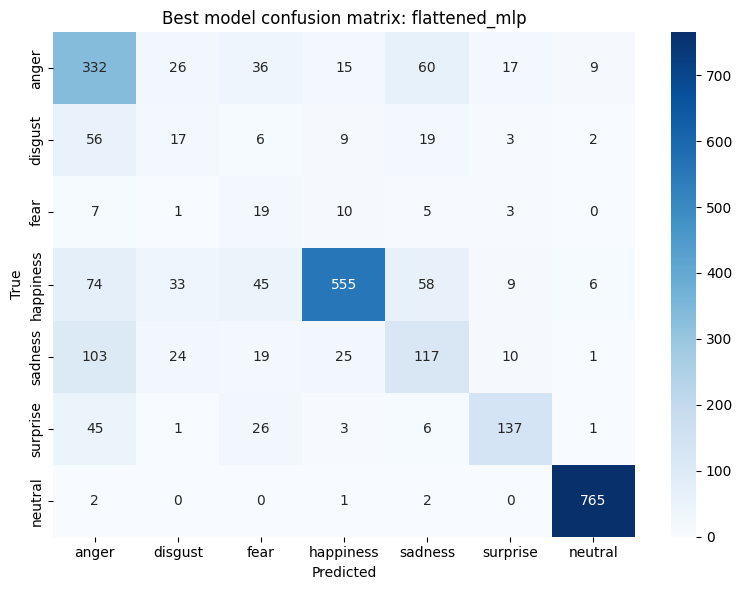

saved: rafdb_precomputed_landmark_graph_run/results/comparison.csv
saved: rafdb_precomputed_landmark_graph_run/results/benchmark_results.json
saved: rafdb_precomputed_landmark_graph_run/results/run_config.json
saved: rafdb_precomputed_landmark_graph_run/results/best_confusion_matrix.png


,model,val_accuracy,val_macro_f1,val_balanced_accuracy,test_accuracy,test_macro_f1,test_balanced_accuracy,latency_ms_per_sample,anger_f1,disgust_f1,fear_f1,happiness_f1,sadness_f1,surprise_f1,neutral_f1
0,flattened_mlp,0.734602,0.582543,0.602384,0.713971,0.547032,0.566662,0.015928,0.596050,0.158879,0.193878,0.793991,0.413428,0.688442,0.984556
1,xgboost_geometry,0.721165,0.517744,0.510085,0.711029,0.520788,0.511956,0.007462,0.592199,0.242038,0.150943,0.781058,0.326882,0.622222,0.930173
2,logreg_geometry,0.631206,0.506800,0.570545,0.624632,0.502519,0.565575,0.000350,0.471526,0.309711,0.185654,0.705080,0.353923,0.576998,0.914739
3,graph_transformer,0.663680,0.511682,0.553620,0.645221,0.490943,0.526976,0.313049,0.466431,0.180851,0.170404,0.756719,0.308748,0.584615,0.968831
4,majority,0.287421,0.063787,0.142857,0.283088,0.063037,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441261


In [12]:
comparison_df = pd.DataFrame(comparison_rows).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)

comparison_path = RESULTS_DIR / 'comparison.csv'
results_path = RESULTS_DIR / 'benchmark_results.json'
config_path = RESULTS_DIR / 'run_config.json'
confusion_path = RESULTS_DIR / 'best_confusion_matrix.png'

comparison_df.to_csv(comparison_path, index=False)
results_path.write_text(json.dumps(results, indent=2, default=str), encoding='utf-8')
config_path.write_text(json.dumps({
    'HF_DATASET_ID': HF_DATASET_ID,
    'SEED': SEED,
    'MAX_SAMPLES_PER_SPLIT': MAX_SAMPLES_PER_SPLIT,
    'LANDMARK_COLUMN': LANDMARK_COLUMN,
    'LANDMARK_IMAGE_SIZE': LANDMARK_IMAGE_SIZE,
    'EXPECTED_SPLITS': EXPECTED_SPLITS,
    'BATCH_SIZE': BATCH_SIZE,
    'NUM_WORKERS': NUM_WORKERS,
    'DEVICE': DEVICE,
    'USE_AMP': USE_AMP,
    'MODEL_KINDS': MODEL_KINDS,
    'TRAINING_CONFIG': TRAINING_CONFIG,
    'GRAPH_TRANSFORMER_CONFIG': GRAPH_TRANSFORMER_CONFIG,
    'FLATTENED_MLP_CONFIG': FLATTENED_MLP_CONFIG,
    'coverage': coverage,
    'coverage_by_split': coverage_by_split,
}, indent=2), encoding='utf-8')

best_model = comparison_df.iloc[0]['model']
best_cm = np.asarray(results['models'][best_model]['test_metrics']['confusion_matrix'])
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Best model confusion matrix: {best_model}')
plt.tight_layout()
plt.savefig(confusion_path, dpi=160)
plt.show()

print('saved:', comparison_path)
print('saved:', results_path)
print('saved:', config_path)
print('saved:', confusion_path)
display(comparison_df)


## Expected Artifacts

After the run finishes, check:

- `rafdb_precomputed_landmark_graph_run/results/comparison.csv`
- `rafdb_precomputed_landmark_graph_run/results/benchmark_results.json`
- `rafdb_precomputed_landmark_graph_run/results/run_config.json`
- `rafdb_precomputed_landmark_graph_run/checkpoints/*_best.pt`

The notebook does not upload anything to Hugging Face.
